In [3]:
import os

try:
    ProgramPath = os.path.dirname(os.path.abspath(file))
except NameError:
    ProgramPath = os.getcwd()

print(ProgramPath)

\\MetroBulk\Public\!Programs\!Metrologia_git


In [8]:
import importlib
import Axes_test_task_01

# Принудительно перечитываем файл с диска
importlib.reload(Axes_test_task_01)
# Теперь забираем обновленный список
EXPERIMENTS = Axes_test_task_01.EXPERIMENTS

#from Axes_test_task_01 import EXPERIMENTS

#None (все), [0] (только первый), [0, 2] (несколько конкретных)
run_only = None  

for num in (run_only or range(len(EXPERIMENTS))):
    
    task = EXPERIMENTS[num]
    
    #координаты ножей
    apt_start, apt_end = task['APT']
    apl_start, apl_end = task['APL']
    apr_start, apr_end = task['APR']
    apb_start, apb_end = task['APB']
    
    #словарь приборов
    devices = task['devices']
    
    print(devices['tonghui_TH2690A'])

{'config': 'PICOAMMETER_TEST_1', 'datanames': ('CURR',)}
{'config': 'PICOAMMETER_TEST_1', 'datanames': ('CURR',)}


In [3]:
from datetime import datetime

def parse_axis_values(value_str):
    # Разбирает строку вида '-6:6' или '20' в кортеж (start, end)
    if ":" in value_str:
        start, end = value_str.split(":")
        return float(start), float(end)
    else:
        # Если передано одно число (например, '20'), то и start, и end равны ему
        val = float(value_str)
        return val, val

def parse_axis_values(value_str):
    # Разбирает '-6:6' или '20' в кортеж (start, end)
    parts = value_str.split(":")
    start, end = parts if len(parts) > 1 else parts * 2
    return float(start), float(end)

# Считывание строк из файла
with open("Axes_test_task_01.txt", "r", encoding="utf-8") as file:
    for line in file:
        
        #1. Отрезаем комментарий, убираем пробелы по краям и режем по табуляции
        parts = line.split('#')[0].strip().split('\t')
        
        #2. Пропускаем строку, если она пустая
        if parts == ['']: continue
        
        #а вот как можно было одной строкой
        #if (parts := line.split('#')[0].strip().split('\t')) == ['']: continue
        
        #3. Заполняем intervals (всегда 5-й элемент по счету)
        intervals = float(parts[4])
        
        #4. Проверяем имя файла (6-й элемент по счету). Если его нет — генерируем пустую строку
        filename = (parts[5:] or [""])[0].strip()
            
        #5. Парсим значения для каждой оси
        apt_start, apt_end = parse_axis_values(parts[0])
        apl_start, apl_end = parse_axis_values(parts[1])
        apr_start, apr_end = parse_axis_values(parts[2])
        apb_start, apb_end = parse_axis_values(parts[3])
        
        #6. Формируем итоговую структуру axes
        axes = [
            {'name': 'APT', 'start': apt_start, 'end': apt_end}, 
            {'name': 'APL', 'start': apl_start, 'end': apl_end}, 
            {'name': 'APR', 'start': apr_start, 'end': apr_end}, 
            {'name': 'APB', 'start': apb_start, 'end': apb_end}
        ]
        
        # --- Вывод результата для проверки ---
        print(f"FILENAME: {filename}")
        print(f"INTERVALS: {intervals}")
        print("AXES:")
        for axis in axes:
            print(f"  {axis}")
        print("-" * 50)

FILENAME: test_file.txt
INTERVALS: 120.0
AXES:
  {'name': 'APT', 'start': -6.0, 'end': 6.0}
  {'name': 'APL', 'start': 20.0, 'end': 20.0}
  {'name': 'APR', 'start': 20.0, 'end': 20.0}
  {'name': 'APB', 'start': 20.0, 'end': 20.0}
--------------------------------------------------
FILENAME: 
INTERVALS: 80.0
AXES:
  {'name': 'APT', 'start': 10.0, 'end': 10.0}
  {'name': 'APL', 'start': -4.0, 'end': 4.0}
  {'name': 'APR', 'start': 10.0, 'end': 10.0}
  {'name': 'APB', 'start': 20.0, 'end': 20.0}
--------------------------------------------------
FILENAME: 
INTERVALS: 80.0
AXES:
  {'name': 'APT', 'start': 10.0, 'end': 10.0}
  {'name': 'APL', 'start': -4.0, 'end': 4.0}
  {'name': 'APR', 'start': 15.0, 'end': 15.0}
  {'name': 'APB', 'start': 20.0, 'end': 20.0}
--------------------------------------------------
FILENAME: test_file_2.txt
INTERVALS: 80.0
AXES:
  {'name': 'APT', 'start': 10.0, 'end': 10.0}
  {'name': 'APL', 'start': -4.0, 'end': 4.0}
  {'name': 'APR', 'start': 20.0, 'end': 20.0}


In [10]:
def Parse_task_file(task_filename):
    
    '''Возвращает список вида:
    
    [
        {'axes' : [{'APT_beg': 10.0, 'APT_end': 10.0},
                   {'APL_beg': -4.0, 'APL_end':  4.0},
                   {'APR_beg': 25.0, 'APR_end': 25.0},
                   {'APB_beg': 20.0, 'APB_end': 20.0},] ,
         'intervals': 120,
         'filename' : 'test_file.txt',
        },
        
        {...},
    ]

    Таким образом, индекс списка - это порядковый индекс эксперимента,
    а индекс списка axes - это индекс оси щели.
    При этом каждый эксперимент является словарем.'''
    
    def parse_axis_values(value_str):
        # Разбираем '-6:6' или '20' в кортеж (start, end)
        parts = value_str.split(":")
        start, end = parts if len(parts) > 1 else parts * 2
        return float(start), float(end)

    #---ПАРСИНГ ТЕКСТОВОГО ФАЙЛА---
    ALL_TASKS = []

    with open(task_filename, "r", encoding="utf-8") as file:
        for line in file:

            #1. Отрезаем комментарий, убираем пробелы по краям и режем по табуляции
            parts = line.split('#')[0].strip().split('\t')

            #2. Пропускаем строку, если она пустая
            if parts == ['']: continue
            
            # а вот как можно было одной строкой
            #if (parts := line.split('#')[0].strip().split('\t')) == ['']: continue

            #3. Заполняем intervals (всегда 5-й элемент по счету)
            intervals = int(parts[4])

            #4. Проверяем имя файла (6-й элемент по счету). Если его нет — оставляем пустым
            filename = (parts[5:] or [""])[0].strip()

            #5. Парсим значения координат и формируем словарь осей
            apt, apl, apr, apb = map(parse_axis_values, parts[:4])

            axes = [
                {'APT_beg': apt[0], 'APT_end': apt[1]},
                {'APL_beg': apl[0], 'APL_end': apl[1]},
                {'APR_beg': apr[0], 'APR_end': apr[1]},
                {'APB_beg': apb[0], 'APB_end': apb[1]}
            ]

            #6. Сохраняем словарь-эксперимент в общий пул
            ALL_TASKS.append({'axes': axes, 'intervals': intervals, 'filename': filename})
    
    return ALL_TASKS
    
Parse_task_file("Axes_test_task_01.txt")

[{'axes': [{'APT_beg': -6.0, 'APT_end': 6.0},
   {'APL_beg': 20.0, 'APL_end': 20.0},
   {'APR_beg': 20.0, 'APR_end': 20.0},
   {'APB_beg': 20.0, 'APB_end': 20.0}],
  'intervals': 120,
  'filename': 'test_file.txt'},
 {'axes': [{'APT_beg': 10.0, 'APT_end': 10.0},
   {'APL_beg': -4.0, 'APL_end': 4.0},
   {'APR_beg': 10.0, 'APR_end': 10.0},
   {'APB_beg': 20.0, 'APB_end': 20.0}],
  'intervals': 80,
  'filename': ''},
 {'axes': [{'APT_beg': 10.0, 'APT_end': 10.0},
   {'APL_beg': -4.0, 'APL_end': 4.0},
   {'APR_beg': 15.0, 'APR_end': 15.0},
   {'APB_beg': 20.0, 'APB_end': 20.0}],
  'intervals': 80,
  'filename': ''},
 {'axes': [{'APT_beg': 10.0, 'APT_end': 10.0},
   {'APL_beg': -4.0, 'APL_end': 4.0},
   {'APR_beg': 20.0, 'APR_end': 20.0},
   {'APB_beg': 20.0, 'APB_end': 20.0}],
  'intervals': 80,
  'filename': 'test_file_2.txt'},
 {'axes': [{'APT_beg': 10.0, 'APT_end': 10.0},
   {'APL_beg': -4.0, 'APL_end': 4.0},
   {'APR_beg': 25.0, 'APR_end': 25.0},
   {'APB_beg': 20.0, 'APB_end': 20.0}],

In [13]:
import os
import configparser

def Read_devices_config(config_filename='Instrument.ini'):
    #Путь к конфигу в корневой папке INI
    config_path = os.path.join('INI', config_filename)
    
    config = configparser.ConfigParser()
    config.read(config_path, encoding='utf-8')
    
    #Считываем абсолютно все секции и их параметры автоматически
    all_devices_dict = {name: dict(config[name]) for name in config.sections()}
        
    return all_devices_dict

Read_devices_config()

{'TH1992B_1': {'libraryname': 'tonghui_TH1992B',
  'connectionmethod': 'TCPIP',
  'deviceaddress': '192.168.88.11',
  'deviceport': '45454'},
 'TH2690A_1': {'libraryname': 'tonghui_TH2690A',
  'connectionmethod': 'TCPIP',
  'deviceaddress': '192.168.88.12',
  'deviceport': '45454'}}

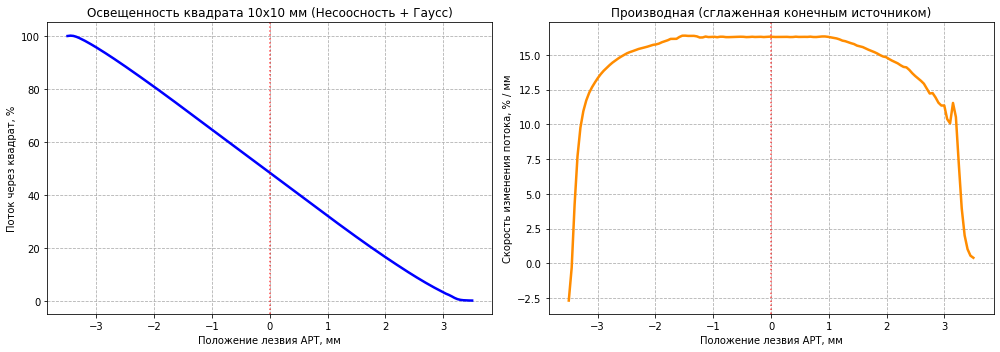

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import fresnel
from scipy.ndimage import gaussian_filter1d

# 1. Параметры геометрии установки (метры)
z_source = 0.0
z_blade = 20.0
z_screen = 30.0

z1 = z_blade - z_source
z2 = z_screen - z_blade

lam = 13.5e-9
M = z_screen / z_blade  # Увеличение ножа = 1.5
L = (z1 * z2) / (z1 + z2) # Приведенное расстояние = 6.667 м
scale_w = np.sqrt(2 / (lam * L)) * 1e-3  # Масштаб для интегралов Френеля

# Параметры источника
fwhm_source = 0.050  # FWHM источника = 50 мкм (0.050 мм)
# Размытие на самом экране за счет геометрии (проекция через нож):
sigma_screen = (fwhm_source * (z2 / z1)) / (2 * np.sqrt(2 * np.log(2))) # переводим FWHM в sigma

# Координаты диафрагм вдоль оси Z
z_diaphs = np.array([24.4, 26.5, 27.5])
r_diaph = 6.0  # Радиус диафрагм (диаметр 12 мм / 2), мм

# 2. ЗАДАНИЕ НЕСООСНОСТЕЙ ДИАФРАГМ (в мм на их собственных позициях)
dx_diaphs = np.array([0.8, -1.2, 0.5])  # Смещения по оси X
dy_diaphs = np.array([-0.5, 1.0, -0.7])  # Смещения по оси Y

# 3. Пересчет проекций центров и радиусов диафрагм на плоскость экрана
centers_x_scr = dx_diaphs * (z_screen / z_diaphs)
centers_y_scr = dy_diaphs * (z_screen / z_diaphs)
radii_scr = r_diaph * (z_screen / z_diaphs)

# 4. Создание двумерной сетки экрана (квадрат 10х10 мм)
points = 800  # разрешение сетки
x_vec = np.linspace(-5, 5, points)
y_vec = np.linspace(-5, 5, points)

# ИСПРАВЛЕНИЕ: берем скалярные значения для шага пикселя
dx_pixel = (x_vec[-1] - x_vec[0]) / (points - 1) 
X, Y = np.meshgrid(x_vec, y_vec)

# Строим маску пропускания: свет должен пройти через ВСЕ ТРИ диафрагмы
mask = (np.abs(X) <= 5) & (np.abs(Y) <= 5)
for cx, cy, r in zip(centers_x_scr, centers_y_scr, radii_scr):
    mask = mask & ((X - cx)**2 + (Y - cy)**2 <= r**2)

# ИСПРАВЛЕНИЕ: площадь одного пикселя — это просто число
dA = dx_pixel * dx_pixel 
total_area = np.sum(mask) * dA

if total_area == 0:
    raise ValueError("Диафрагмы смещены настолько сильно, что полностью перекрыли пучок!")


# 5. Дифракционная функция лезвия
def get_I_blade(x, apt):
    w = scale_w * (x - M * apt)
    S, C = fresnel(w)
    return 0.5 * ((C + 0.5)**2 + (S + 0.5)**2)

# Перевод физического sigma_screen в пиксели сетки для свертки
sigma_pixels = sigma_screen / dx_pixel

# 6. Расчет профиля светового потока
apt_range = np.linspace(-3.5, 3.5, 140)
power_profile = []

for apt in apt_range:
    I_x = get_I_blade(x_vec, apt)
    
    # СВЁРТКА С ГАУССОВЫМ ИСТОЧНИКОМ вдоль оси дифракции X
    I_x_blurred = gaussian_filter1d(I_x, sigma=sigma_pixels, mode='nearest')
    
    I_2d = np.tile(I_x_blurred, (points, 1))
    total_power = np.sum(I_2d * mask) * dA
    power_profile.append(total_power / total_area * 100)

power_profile = np.array(power_profile)

# 7. Расчет производной (Численное дифференцирование dP/dAPT)
derivative = -np.gradient(power_profile, apt_range)

# 8. Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График интегральной освещенности
ax1.plot(apt_range, power_profile, color='blue', lw=2.5, label='Световой поток $P(APT)$')
ax1.set_title('Освещенность квадрата 10х10 мм (Несоосность + Гаусс)')
ax1.set_xlabel('Положение лезвия APT, мм')
ax1.set_ylabel('Поток через квадрат, %')
ax1.grid(True, linestyle='--')
ax1.axvline(0, color='red', linestyle=':', alpha=0.7)

# График производной (чувствительности)
ax2.plot(apt_range, derivative, color='darkorange', lw=2.5, label='Производная $-dP/dAPT$')
ax2.set_title('Производная (сглаженная конечным источником)')
ax2.set_xlabel('Положение лезвия APT, мм')
ax2.set_ylabel('Скорость изменения потока, % / мм')
ax2.grid(True, linestyle='--')
ax2.axvline(0, color='red', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()
